**NDA EXAMPLE NOTEBOOK**

This notebook shows example for plotting Stokes I and V calibrated NDA (Nançay Decameter Array) data. NDA records two channels, which correspond to left and right circular polarisations from 10 to 88 MHz.

**Workflow**: Fido query and download data -> load the fits -> extract LL & RR -> plot Stokes I and V -> plot for a selected time interval -> calibrate LL and RR -> Plot stokes I and V

In [1]:

from astropy.io import fits
import numpy as np
from astropy.time import Time
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from radiospectra import net
from sunpy.net import Fido, attrs as a
import astropy.units as u


**Fido Query to request the NDA data and download it**

In [2]:
query = Fido.search(a.Time("2025-03-26", "2025-03-27"),a.Instrument("NDA"))
print(query)
## download file
dir_path = '/Users/shilpibhunia/Documents/projects/NDA_analysis/'  ## path of directory to store the data
files = Fido.fetch(query,path=dir_path+"/{instrument}/{file}")
print(files)

Results from 1 Provider:

1 Results from the NDAClient:
Source: https://cdn.obs-nancay.fr/repository/nda/newroutine/soleil/

       Start Time             End Time      Instrument  Physobs    Provider Source Version
----------------------- ------------------- ---------- ---------- --------- ------ -------
2025-03-26 07:56:00.000 2025-03-26 15:55:00        NDA radio_flux OBSNANCAY    NDA     1.1




Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['/Users/shilpibhunia/Documents/projects/NDA_analysis/NDA/orn_nda_newroutine_sun_edr_202503260756_202503261555_v1.1.fits']


**Read FITS file**

In [3]:
print('Reading the file...')

fitsfile = files[0]
hdul = fits.open(fitsfile)
hdul.info()


Reading the file...
Filename: /Users/shilpibhunia/Documents/projects/NDA_analysis/NDA/orn_nda_newroutine_sun_edr_202503260756_202503261555_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      75   ()      
  1  SETUP         1 BinTableHDU     12   1R x 1C   [1598E]   
  2  SCIENCE       1 BinTableHDU     16   58522R x 2C   [1D, 3196E]   
  3  ACQUISITION    1 BinTableHDU     36   539R x 9C   [1D, 1E, 1E, 1E, 1E, 1I, 1I, 1I, 1I]   


**Get frequency and time**

In [4]:
freq = hdul[1].data[0][0]
times = []
for i in range(hdul[2].data.shape[0]):
    t = Time(hdul[2].data[i][0], format='jd')
    t = datetime.strptime(t.to_value('isot'), '%Y-%m-%dT%H:%M:%S.%f')
    times.append(t)

times = np.array(times)
print(times)
print(freq)

[datetime.datetime(2025, 3, 26, 7, 56, 27, 260000)
 datetime.datetime(2025, 3, 26, 7, 56, 27, 752000)
 datetime.datetime(2025, 3, 26, 7, 56, 28, 244000) ...
 datetime.datetime(2025, 3, 26, 15, 55, 58, 908000)
 datetime.datetime(2025, 3, 26, 15, 55, 59, 400000)
 datetime.datetime(2025, 3, 26, 15, 55, 59, 892000)]
[10.009766 10.058594 10.107422 ... 87.890625 87.93945  87.98828 ]


**Extract left and right polarised data**

In [5]:
data  = hdul[2].data
ldata = np.array([row[1][:, 0] for row in data])
rdata = np.array([row[1][:, 1] for row in data])
print("ldata shape:", ldata.shape)
print("rdata shape:", rdata.shape)

ldata shape: (58522, 1598)
rdata shape: (58522, 1598)


**Compute Stokes I and V**

In [6]:
I = (ldata + rdata) / 2.0
V = (ldata - rdata) / 2.0

**Plot Stokes I and V**

After 2020, due to incorrect pointing toward the Sun, fringe-like structures have been continuously observed in the L-band data. Therefore, the Stokes V spectra should be interpreted with caution.

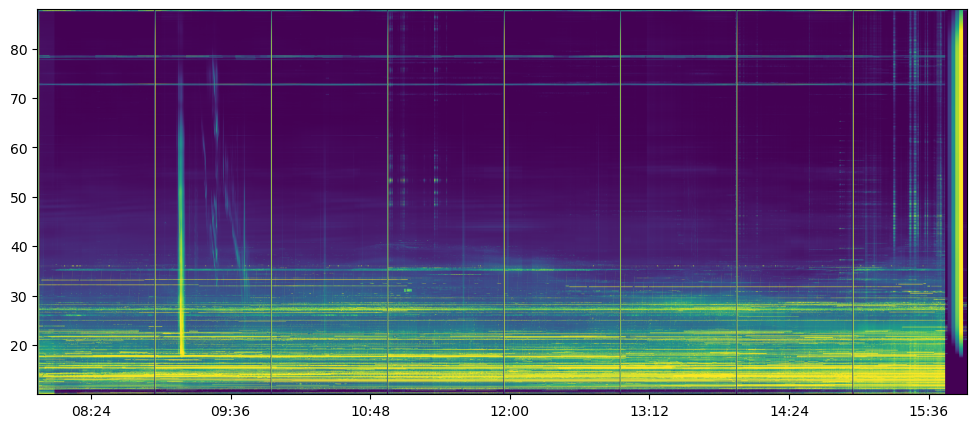

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))
times_num = mdates.date2num(times)
vmin_I = np.nanpercentile(I, 5)
vmax_I = np.nanpercentile(I, 95)
im = ax1.imshow(
    I.T,
    aspect='auto',
    origin='lower',
    norm=LogNorm(vmin=vmin_I, vmax=vmax_I),
    extent=[times_num[0], times_num[-1], freq[0], freq[-1]]
)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.show()

**Get data for a particular time interval**

In [8]:
startt = datetime(2025, 3, 26, 9, 21) 
endt   = datetime(2025, 3, 26, 9, 51)

startid = np.argmin(np.abs(times - startt))
endid   = np.argmin(np.abs(times - endt))

Times = times[startid:endid]

I_cut = I[startid:endid]
V_cut = V[startid:endid]


**Plot I and V data for the chosen time interval**

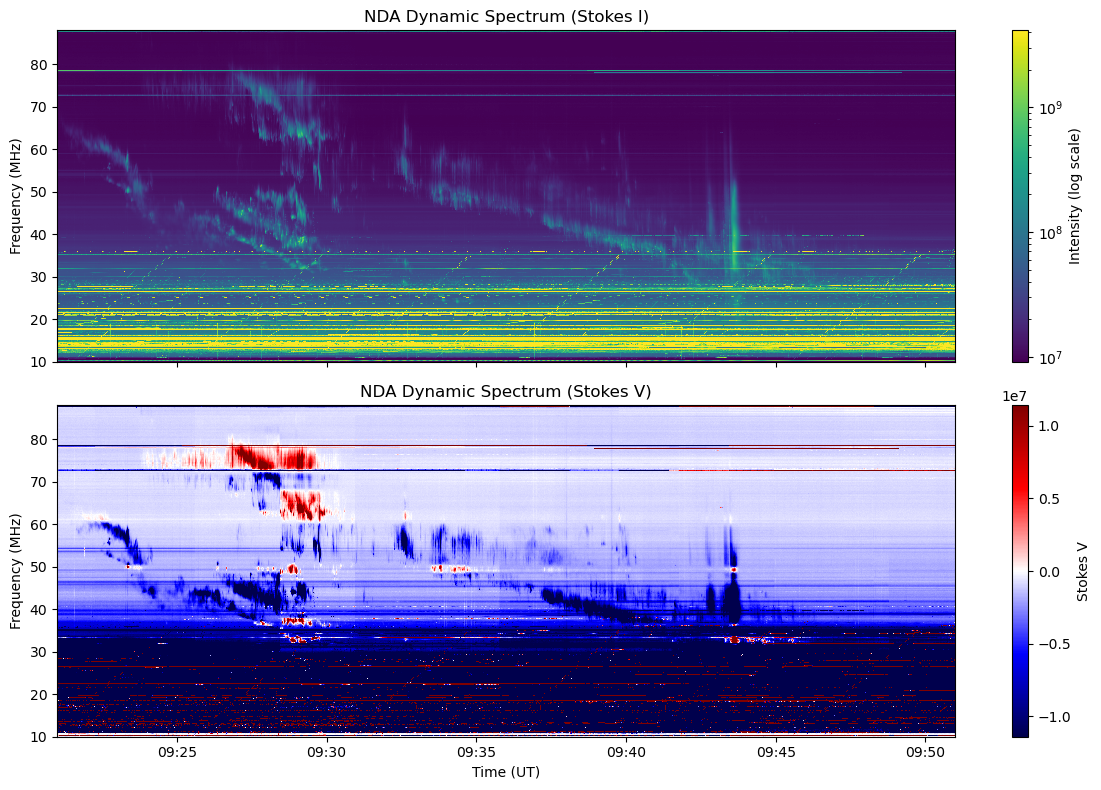

In [9]:
# For I (log scale)
I[I <= 0] = np.nan
vmin_I = np.nanpercentile(I, 5)
vmax_I = np.nanpercentile(I, 95)

# For V (symmetric scale)
vmax_V = np.nanpercentile(np.abs(V), 70)

time_nums = mdates.date2num(Times)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ---- Stokes I ----
im1 = axs[0].pcolormesh(time_nums, freq, I_cut.T,
                        shading='auto',
                        cmap='viridis',
                        norm=LogNorm(vmin=vmin_I, vmax=vmax_I))

axs[0].set_ylabel('Frequency (MHz)')
axs[0].set_title('NDA Dynamic Spectrum (Stokes I)')
#axs[0].invert_yaxis()

cbar1 = plt.colorbar(im1, ax=axs[0])
cbar1.set_label('Intensity (log scale)')

# ---- Stokes V ----
im2 = axs[1].pcolormesh(time_nums, freq, V_cut.T,
                        shading='auto',
                        cmap='seismic',
                        vmin=-vmax_V,
                        vmax=+vmax_V)

axs[1].set_ylabel('Frequency (MHz)')
axs[1].set_title('NDA Dynamic Spectrum (Stokes V)')
#axs[1].invert_yaxis()

cbar2 = plt.colorbar(im2, ax=axs[1])
cbar2.set_label('Stokes V')

# ---- Time axis formatting ----
axs[1].xaxis_date()
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel('Time (UT)')

plt.tight_layout()

**Now calibrate the data**

In [12]:
import sys
### give the path of calibration_NDA function
sys.path.append("/Users/shilpibhunia/Documents/projects/NDA_analysis/scripts/calib_tool")
from test_calibration_NDA import calib_NDA_V1
## Get LL and RR data in Jansky
LL_jy, RR_jy, nda_time, freq = calib_NDA_V1(files[0],thres_calib = 8E9,pplot=False, check=False)


Observing time: 7.940833333333334 / 15.93323097323378
Resolution: 0.49166339635849
Network 0 / Coeff [[ 12.18212722   0.        ]
 [-72.45688657   0.        ]] / XX [ 7.75776159  8.32448573  9.20176446 10.16690238]
Network 1 / Coeff [[ 12.18212722  12.07695687]
 [-72.45688657 -70.59141534]] / XX [ 7.67778396  8.22887854  9.13815088 10.09695835]


**Plot left and right polarisation**

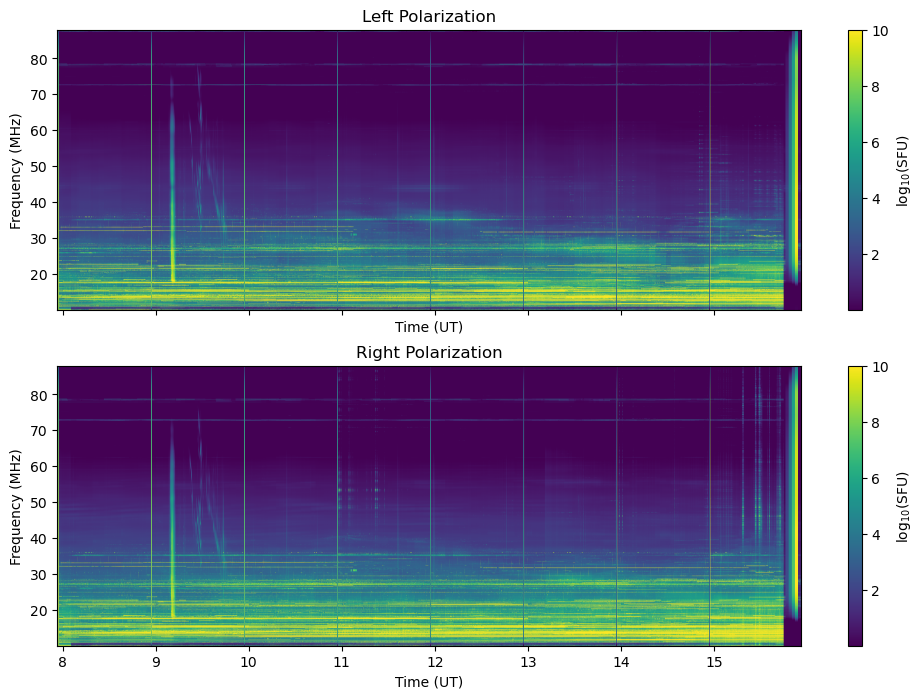

In [14]:
vmin = 1e-2 
vmax = 10 # 1E5SFU
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8),sharex=True,sharey=True)
im1 = ax1.imshow(np.log(LL_jy.T/1E4) ,vmin=vmin,vmax=vmax,
    aspect='auto',extent=[nda_time.min(), nda_time.max(), freq.min(), freq.max()],cmap='viridis')
ax1.set_title(f"Left Polarization")
ax1.set_xlabel('Time (UT)')
ax1.set_ylabel('Frequency (MHz)')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('log$_{10}$(SFU)')

im2 = ax2.imshow(np.log(RR_jy.T/1E4),vmin=vmin,vmax=vmax,
    aspect='auto',extent=[nda_time.min(), nda_time.max(), freq.min(), freq.max()],cmap='viridis')
ax2.set_title('Right Polarization')
ax2.set_xlabel('Time (UT)')
ax2.set_ylabel('Frequency (MHz)')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log$_{10}$(SFU)')

**Plot Stokes I and V**

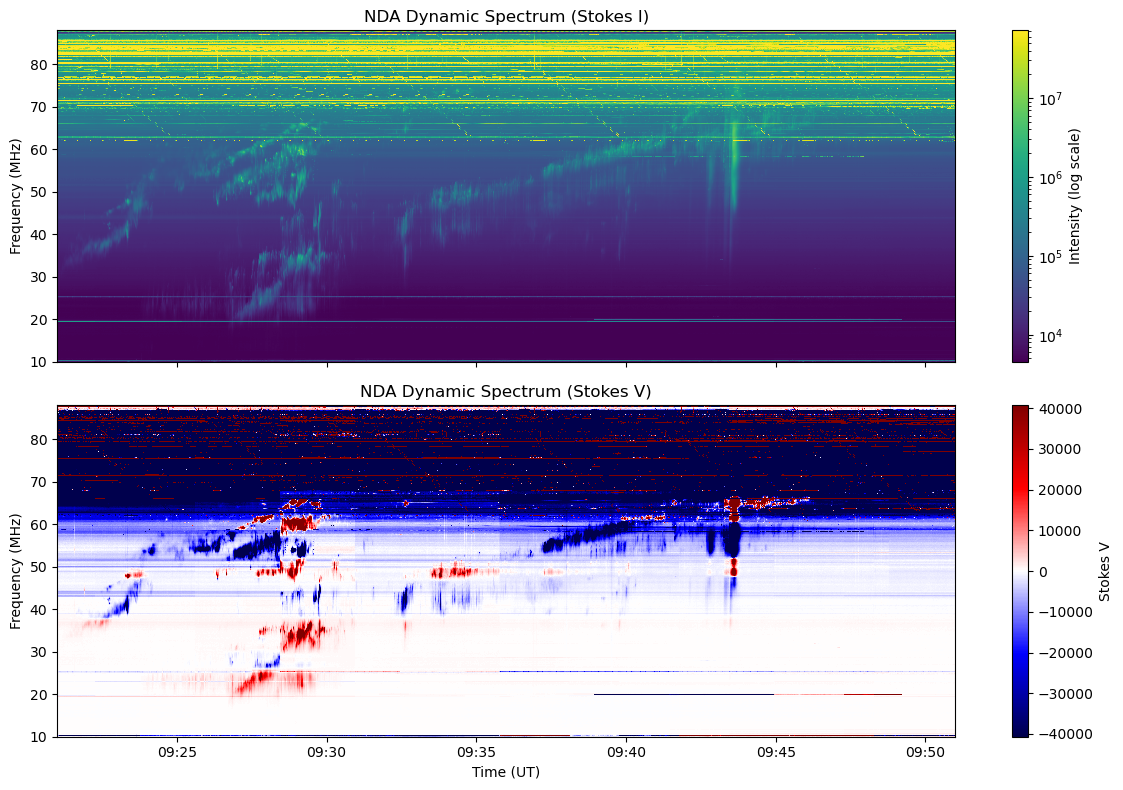

In [16]:
I = (LL_jy + RR_jy) / 2.0
V = (LL_jy - RR_jy) / 2.0
### get I and V data for the time range
I_cut = I[startid:endid]
V_cut = V[startid:endid]

#### Plot stokes I and V
# For I (log scale)
I[I <= 0] = np.nan
vmin_I = np.nanpercentile(I, 5)
vmax_I = np.nanpercentile(I, 95)

# For V (symmetric scale)
vmax_V = np.nanpercentile(np.abs(V), 70)

time_nums = mdates.date2num(Times)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ---- Stokes I ----
im1 = axs[0].pcolormesh(time_nums, freq, I_cut.T,
                        shading='auto',
                        cmap='viridis',
                        norm=LogNorm(vmin=vmin_I, vmax=vmax_I))

axs[0].set_ylabel('Frequency (MHz)')
axs[0].set_title('NDA Dynamic Spectrum (Stokes I)')
#axs[0].invert_yaxis()

cbar1 = plt.colorbar(im1, ax=axs[0])
cbar1.set_label('Intensity (log scale)')

# ---- Stokes V ----
im2 = axs[1].pcolormesh(time_nums, freq, V_cut.T,
                        shading='auto',
                        cmap='seismic',
                        vmin=-vmax_V,
                        vmax=+vmax_V)

axs[1].set_ylabel('Frequency (MHz)')
axs[1].set_title('NDA Dynamic Spectrum (Stokes V)')
#axs[1].invert_yaxis()

cbar2 = plt.colorbar(im2, ax=axs[1])
cbar2.set_label('Stokes V')

# ---- Time axis formatting ----
axs[1].xaxis_date()
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel('Time (UT)')

plt.tight_layout()